<!--Información del curso-->
<img align="left" style="padding-right:10px;" src="figuras/banner_dl.png">


<br><br><center><h1 style="font-size:2em;color:#2467C0">Caso de estudio:  Reconocimiento de dígitos escritos a mano  </h1></center>
<br>
<table>
<col width="550">
<col width="450">
<tr>
    
    
<td><img src="figuras/MnistExamples.png" align="middle" style="width:550px;"/></td>
<td>

La base de datos MNIST (base de datos modificada del Instituto Nacional de Estándares y Tecnología) cuenta con 70,000 pequeñas imágenes de dígitos escritas a mano por estudiantes de secundaria y empleados de la Oficina del Censo de EE. UU.  Cada imagen está etiquetada con el dígito que representa, además cada una tiene 784 características (28 × 28 píxeles) y cada característica simplemente representa la intensidad de un píxel, de 0 (blanco) a 255 (negro).
    
   
<br>
</td>
</tr>
</table>

**Figura: Ejemplo de un número y la división estándar**
<img src="figuras/Mnist.png" align="middle" style="width:550px;"/>


## 1. Obtenga los datos

Algunas fuentes: 

https://bit.ly/MnCD20     (Este tutorial)

http://yann.lecun.com/exdb/mnist/

https://www.kaggle.com/c/digit-recognizer/data?select=sample_submission.csv



In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

In [2]:
#Cargar el archivo de test datos/mnist_test_clase.txt  (2,000 números)
df_test = pd.read_csv('datos/mnist_test_clase.txt', header=None, dtype='uint8')
print(df_test.shape) #Imagenes 28x28 = 784 + 1 columna etiqueta la columna 0
df_test.head()

(501, 785)


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
#Cargar el archivo de entrenamiento datos/mnist_train_clase.txt    
df_train = pd.read_csv('datos/mnist_train_clase.txt', header=None, dtype='uint8')

## 2. Entendiendo la base de datos MNIST

In [4]:
# Mostrar los primeras filas del archivo de entrenamiento
# No tienen encabezado las columnas
# Columna 0: es el target o el digito escrito a mano
# Columna 1 a la 784: Pixeles en escala de 0 a 255
# Cada píxel tiene un valor de brillo comprendido entre 0 (negro) y 255 (blanco). 

In [5]:
#df_train.head()
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Encontrar el número 5 en el set de entrenamiento y mostrarlo

In [6]:
#Definir una variable que guarde los identificadores, es decir la primera columna
y_etiqueta = df_train.iloc[:, 0]
y_etiqueta

0       5
1       0
2       4
3       1
4       9
       ..
1996    5
1997    5
1998    2
1999    0
2000    5
Name: 0, Length: 2001, dtype: uint8

In [7]:
#Crear una mascara para encontrar el indice de las filas con el número 5
y_etiqueta[y_etiqueta == 5]

0       5
11      5
35      5
47      5
65      5
       ..
1991    5
1993    5
1996    5
1997    5
2000    5
Name: 0, Length: 181, dtype: uint8

In [8]:
# Guardar alguna fila en una variable llamada num5
num5 = df_train.iloc[11,1:].values.reshape(28,28) #Fila 0 y de columna 1 hacia adelante.
num5

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

<function matplotlib.pyplot.show(close=None, block=None)>

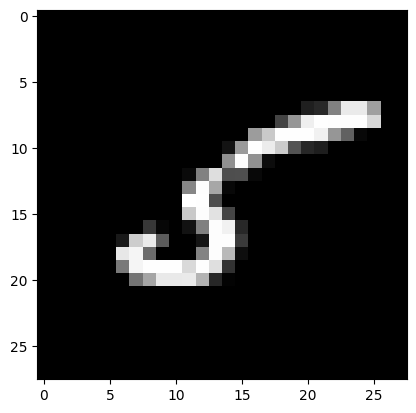

In [9]:
# Graficar la imagen del numero 5
plt.imshow(num5,cmap='gray')
plt.show

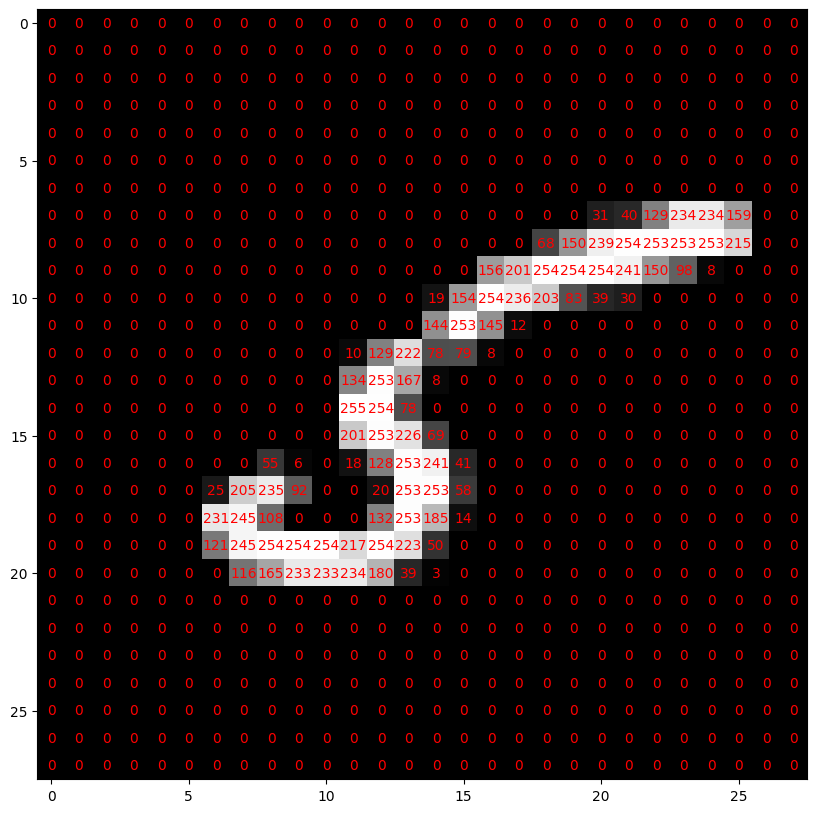

In [10]:
# mostrar los elementos que componen el arreglo sobre la imagen del numero 5
plt.figure(figsize=(10,10))
plt.imshow(num5,cmap='gray')
for (j,i), label in np.ndenumerate(num5):
    plt.text(i,j,label,ha='center',va='center',color='red')
plt.show()

## 3. Prepare los datos 

#### División general de los datos


<img  align="middle" style="width:350px;" src="figuras/ml_diagrama3.jpg">



* **X**: Datos sin el diagnostico es decir sin la columna "target"
* **y**: Datos con el diagnostico es decir con la columna "target"

Muestras de entrenamiento y prueba
* **X_train**: este será el grupo de entrenamiento
* **X_test**: este será el  grupo de prueba
* **y_train**: este será el target para el grupo de entrenamiento
* **y_test**: este será el target para el grupo de prueba

In [11]:
df_train.head(2)

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# Definir los conjuntos de datos de las muestras de entrenamiento y prueba
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]

X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]

## 4. Definimos el pipeline y el clasificador

<img src="figuras/pipeline.jpg" align="middle" style="width:500px;" />

In [13]:
#Definir el pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

steps = [('scaler', StandardScaler()), 
         ('SVM', SVC(kernel = 'poly'))] 

modelo_SVM= Pipeline(steps)


## 5. Realizamos el tuning 

In [14]:
#Parámetros
# C = [0.0001,0.001]
# gamma = [20,10]

parametros={ 'SVM__C': [0.0001,0.001],  
             'SVM__gamma': [20,10] } 

In [15]:
#Realizar el tuning
from sklearn.model_selection import GridSearchCV
grid_SVM = GridSearchCV(modelo_SVM, parametros, cv=5, n_jobs=-1, verbose=5)

In [16]:
#Ajuste
grid_SVM.fit(X_train,y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END ......SVM__C=0.0001, SVM__gamma=20;, score=0.898 total time=   5.6s
[CV 5/5] END ......SVM__C=0.0001, SVM__gamma=20;, score=0.892 total time=   5.5s
[CV 4/5] END ......SVM__C=0.0001, SVM__gamma=20;, score=0.892 total time=   5.8s
[CV 2/5] END ......SVM__C=0.0001, SVM__gamma=10;, score=0.835 total time=   6.0s
[CV 3/5] END ......SVM__C=0.0001, SVM__gamma=10;, score=0.850 total time=   5.7s
[CV 1/5] END ......SVM__C=0.0001, SVM__gamma=10;, score=0.898 total time=   5.9s
[CV 2/5] END ......SVM__C=0.0001, SVM__gamma=20;, score=0.835 total time=   6.1s
[CV 3/5] END ......SVM__C=0.0001, SVM__gamma=20;, score=0.850 total time=   6.1s
[CV 5/5] END ......SVM__C=0.0001, SVM__gamma=10;, score=0.892 total time=   5.7s
[CV 1/5] END .......SVM__C=0.001, SVM__gamma=20;, score=0.898 total time=   5.7s
[CV 3/5] END .......SVM__C=0.001, SVM__gamma=20;, score=0.850 total time=   5.9s
[CV 5/5] END .......SVM__C=0.001, SVM__gamma=20;,

,estimator,Pipeline(step...nel='poly'))])
,param_grid,"{'SVM__C': [0.0001, 0.001], 'SVM__gamma': [20, 10]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,5
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [17]:
#mostrar los mejores valores del tuning
grid_SVM.best_params_

{'SVM__C': 0.0001, 'SVM__gamma': 20}

## 6. Probamos el clasificador SVM

**Exactitud (Accuracy)**:
La exactitud es una medida de la proporción de predicciones correctas que realiza el modelo sobre el total de predicciones realizadas. Se calcula como la proporción entre el número de predicciones correctas y el número total de predicciones. Matemáticamente, se expresa como:


<img align="left" style="padding-right:5px;" src="figuras/img_accuracy.png">


In [18]:
# Realizar la predicción en los datos de test
y_pred = grid_SVM.predict(X_test)

In [19]:
# Los guardamos en una archivo llamado  mnist_prediccion_clase.txt
np.savetxt('mnist_prediccion_clase.txt',y_pred, fmt='%d' , delimiter=',')

In [20]:
#Mostramos el accuracy_score
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8982035928143712

In [21]:
#mostrar la predicción para los primeros 10 valores de prueba
y_test[0:10].values


array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8)

In [22]:
#mostrar los valores reales de los primeros 10 valores de prueba
y_pred[0:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 4, 9], dtype=uint8)

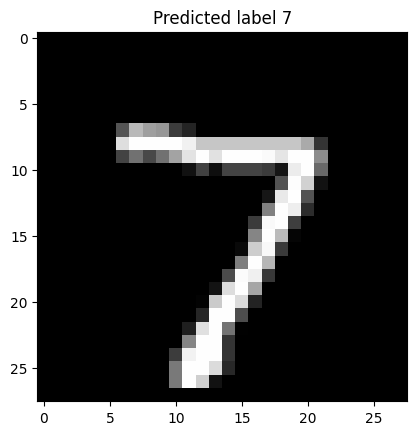

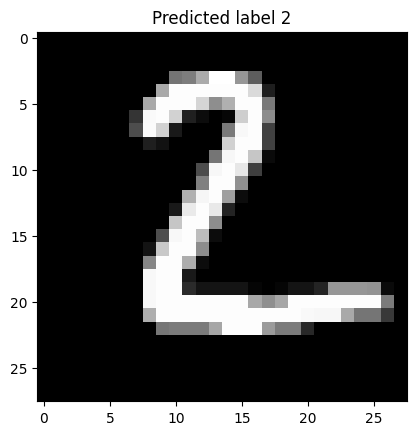

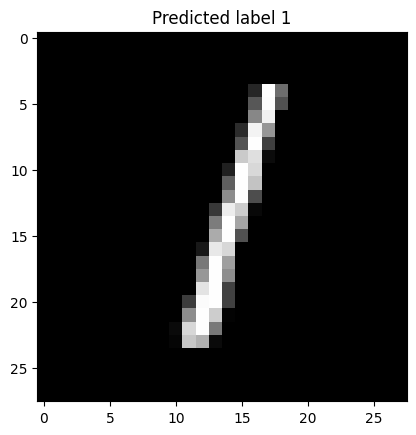

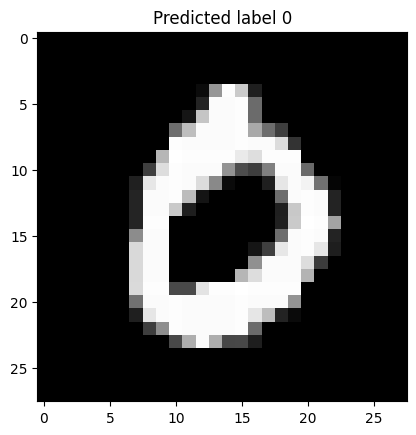

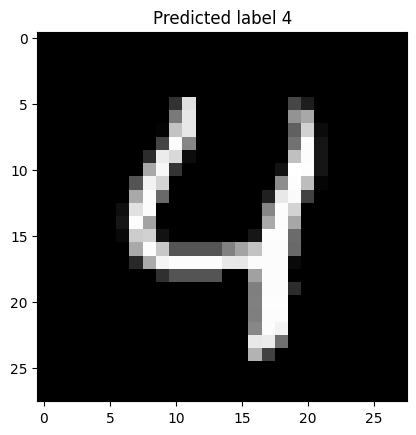

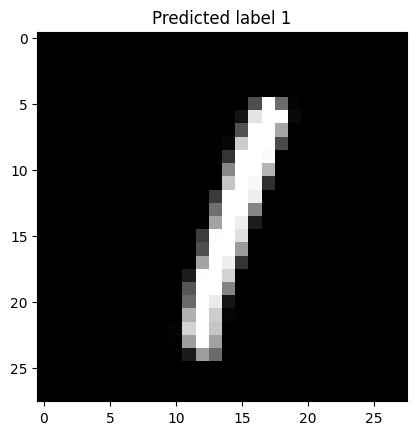

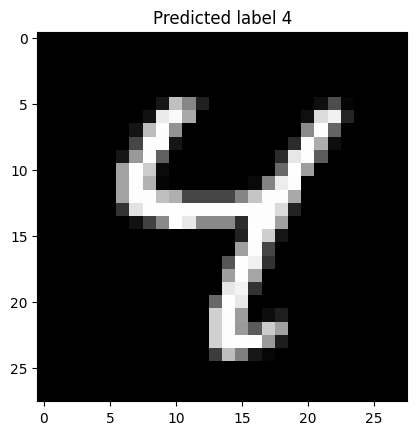

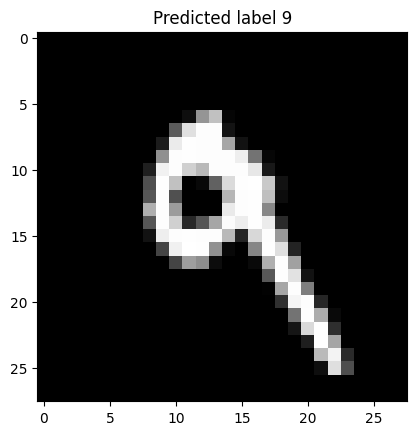

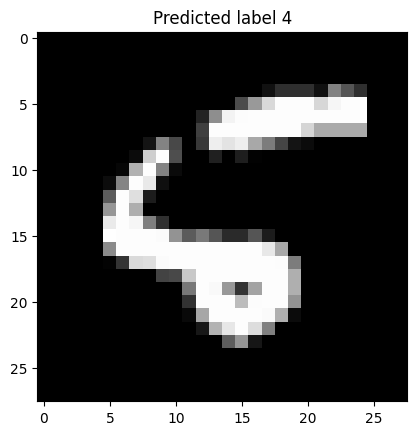

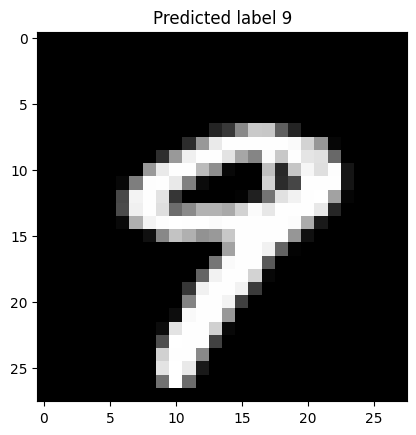

In [23]:
#Mostrar la prediccion y el número
for i in range(10):
    img=X_test.values[i].reshape((28,28))
    plt.title('Predicted label {0}'.format(y_pred[i]))
    plt.imshow(img,cmap='gray')
    plt.show()

### Probamos el clasificador SVM en nuestros propios números

In [24]:
#Cargar el archivo de mis números 'datos/mis_numeros.csv'
df_mn = pd.read_csv('datos/mis_numeros_JOSE_AQUE.csv', header=None, dtype='uint8')
df_mn.shape

(10, 785)

In [25]:
#Definir una variable X, y,  para nuestros números

X_mn=df_mn.iloc[:,1:] #Numeros
y_mn=df_mn.iloc[:,0] #Target

In [26]:
#Realizar la predicción en nuestros números
y_pred_mn = grid_SVM.predict(X_mn)

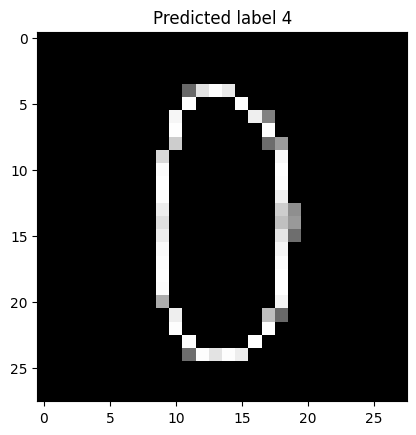

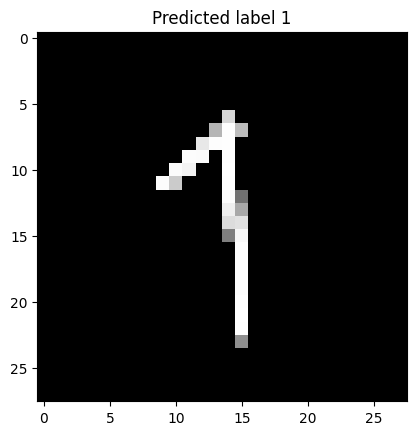

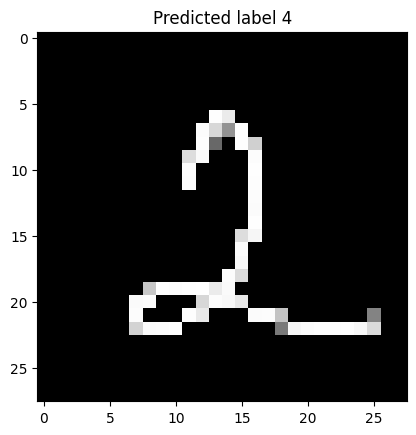

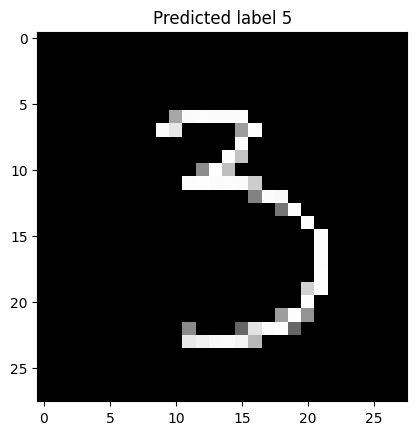

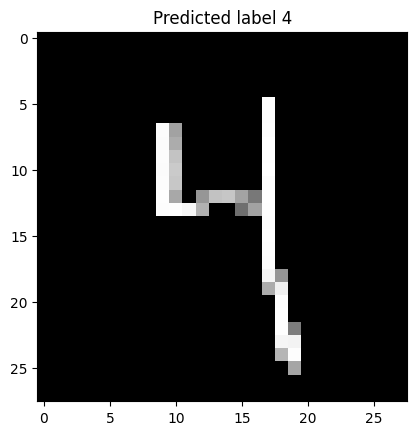

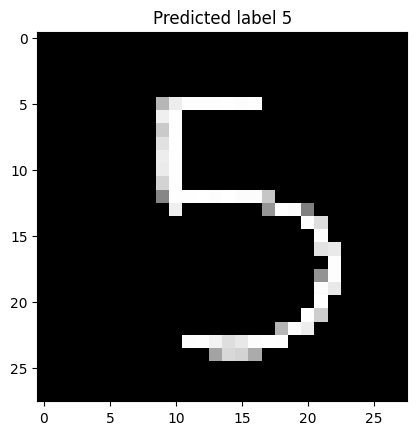

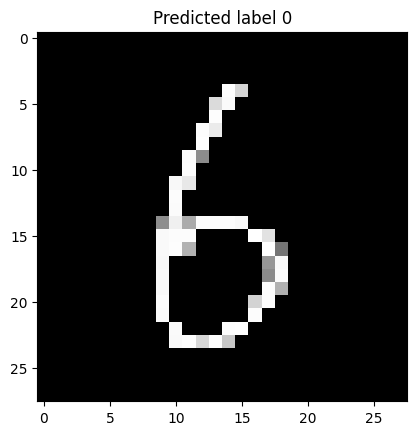

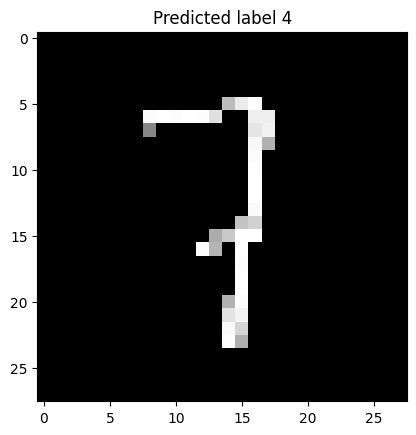

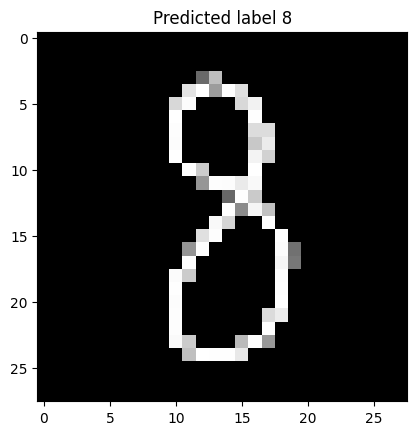

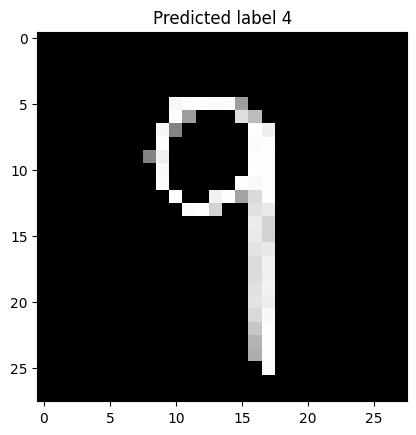

In [27]:
# Comparar la predicción con los valores reales
for i in range(10):
    img=X_mn.values[i].reshape((28,28))
    plt.title('Predicted label {0}'.format(y_pred_mn[i]))
    plt.imshow(img,cmap='gray')
    plt.show()

## 7. Matriz de confusión

### Casos posibles


Tomamos elementos de la muestra de prueba o test
<img src="figuras/PositivosNegativos.png" align="middle" style="width:650px;"/></td>

### Caso 1 : Verdaderos Negativos (VN)

Cuando los negativos que fueron clasificados correctamente como negativos por el modelo.

<img src="figuras/caso1.jpg" align="middle" style="width:750px;"/></td>


### Caso 2 : Verdaderos Positivos (VP)

Cuando los positivos que fueron clasificados correctamente como positivos por el modelo.

<img src="figuras/caso2.jpg" align="middle" style="width:750px;"/></td>

### Caso 3 : Falsos Positivos (FP)

Cuando los negativos que fueron clasificados incorrectamente como positivos. Error tipo 1 (Falsos positivos)

<img src="figuras/caso3.jpg" align="middle" style="width:750px;"/></td>


### Caso 4 : Falsos Negativos

Cuando los positivos que fueron clasificados incorrectamente como negativos. Error tipo 2 (Falsos Negativos)

<img src="figuras/caso4a.jpg" align="middle" style="width:750px;"/></td>



### Matriz de confusión 

La matriz de confusión es una herramienta que permite la visualización del desempeño de un algoritmo de ML. Cada columna de la matriz representa las predicciones de cada clase, mientras que cada fila representa a las instancias reales. Uno de los beneficios de las matrices de confusión es que facilitan ver si el sistema está confundiendo las diferentes clases o resultadosde la clasificación.

<br>

<img src="figuras/Matriz_resumen_s.jpg" align="middle" style="width:550px;"/></td>


#### Sobre los datos de prueba  MNIST

<Axes: xlabel='Predicted', ylabel='Actual'>

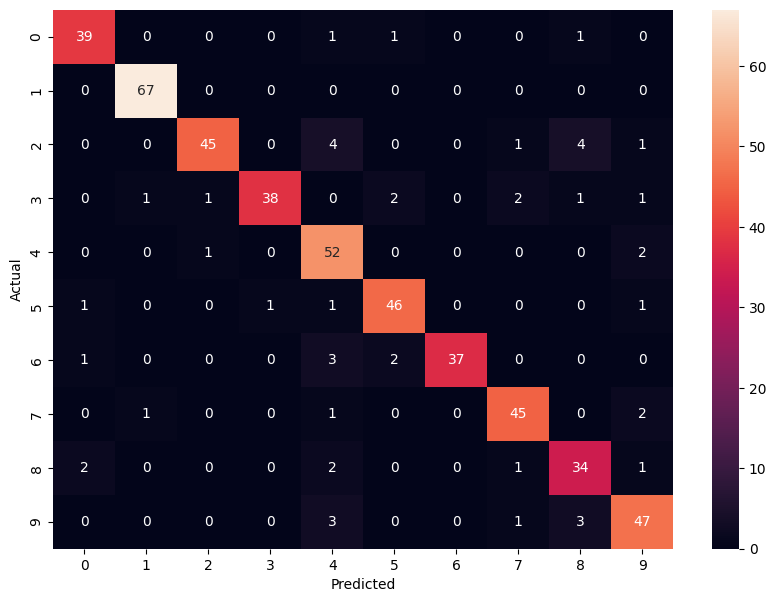

In [28]:
import seaborn as sn
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sn

array=confusion_matrix(y_test,y_pred)
df_cm=pd.DataFrame(array,index=[i for i in range(10)],
                  columns=[i for i in range(10)])
df_cm.index.name='Actual'
df_cm.columns.name='Predicted'
plt.figure(figsize=(10,7))
sn.heatmap(df_cm, annot=True,fmt='d')

#### 1. Utilizando el mismo procedimiento del tutorial , encontrar la matriz de confusión para sus números. 

In [29]:
df_mn=pd.read_csv('datos/mis_numeros_JOSE_AQUE.csv',header=None,dtype='uint8')
X_mn=df_mn.iloc[:,1:]
y_mn=df_mn.iloc[:,0]
y_pred_mn=grid_SVM.predict(X_mn)

<Axes: xlabel='Predicted', ylabel='Actual'>

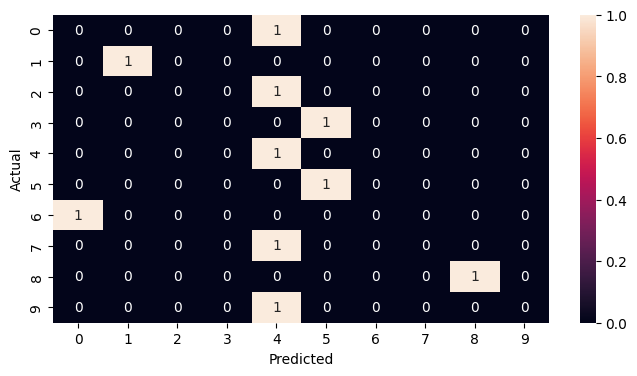

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sn

array=confusion_matrix(y_mn,y_pred_mn)
df_cm=pd.DataFrame(array,index=[i for i in range(10)],
                  columns=[i for i in range(10)])
df_cm.index.name='Actual'
df_cm.columns.name='Predicted'
plt.figure(figsize=(8,4))
sn.heatmap(df_cm, annot=True)

#  Tarea:
* Encontrar un modelo de aprendizaje automático con el mejor desempeño posible para los datos de entrenamiento (datos/mnist_train_tarea.txt) y prueba (datos/mnist_test_tarea.txt).
* Evaluar el archivo datos/mnist_evaluacion_pixeles.txt, asignar etiquetas a los datos y guardar los resultados en un archivo de texto.
     * np.savetxt('NOMBRE1_NOMBRE2_NOMBRE3.txt', y_pred, fmt='%d', delimiter=',')

In [32]:
df_test_tarea = pd.read_csv('datos/mnist_test_tarea.txt', header=None, dtype='uint8')
df_test_tarea.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
df_train_tarea = pd.read_csv('datos/mnist_train_tarea.txt', header=None, dtype='uint8')
df_train_tarea.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
# Definir los conjuntos de datos de las muestras de entrenamiento y prueba
X_train_tarea = df_train_tarea.iloc[:, 1:]
y_train_tarea = df_train_tarea.iloc[:, 0]

X_test_tarea = df_test_tarea.iloc[:, 1:]
y_test_tarea = df_test_tarea.iloc[:, 0]

In [39]:
#Definir el pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

steps = [('scaler', StandardScaler()), 
         ('SVM', SVC(kernel = 'poly'))] 

modelo_SVM= Pipeline(steps)


In [40]:
#Parámetros
# C = [0.0001,0.001]
# gamma = [20,10]

parametros={ 'SVM__C': [0.0001,0.001],  
             'SVM__gamma': [20,10] } 

In [41]:
#Realizar el tuning
from sklearn.model_selection import GridSearchCV
grid_SVM = GridSearchCV(modelo_SVM, parametros, cv=5, n_jobs=-1, verbose=5)

In [42]:
#Ajuste
grid_SVM.fit(X_train_tarea,y_train_tarea)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 3/5] END ......SVM__C=0.0001, SVM__gamma=20;, score=0.954 total time= 1.9min
[CV 1/5] END ......SVM__C=0.0001, SVM__gamma=10;, score=0.953 total time= 1.9min
[CV 2/5] END ......SVM__C=0.0001, SVM__gamma=10;, score=0.963 total time= 1.9min
[CV 4/5] END ......SVM__C=0.0001, SVM__gamma=20;, score=0.944 total time= 2.0min
[CV 3/5] END ......SVM__C=0.0001, SVM__gamma=10;, score=0.954 total time= 2.0min
[CV 2/5] END ......SVM__C=0.0001, SVM__gamma=20;, score=0.963 total time= 2.0min
[CV 1/5] END ......SVM__C=0.0001, SVM__gamma=20;, score=0.953 total time= 2.0min
[CV 5/5] END ......SVM__C=0.0001, SVM__gamma=20;, score=0.961 total time= 2.0min
[CV 2/5] END .......SVM__C=0.001, SVM__gamma=20;, score=0.963 total time= 1.9min
[CV 4/5] END ......SVM__C=0.0001, SVM__gamma=10;, score=0.944 total time= 1.9min
[CV 1/5] END .......SVM__C=0.001, SVM__gamma=20;, score=0.953 total time= 2.0min
[CV 3/5] END .......SVM__C=0.001, SVM__gamma=20;,

,estimator,Pipeline(step...nel='poly'))])
,param_grid,"{'SVM__C': [0.0001, 0.001], 'SVM__gamma': [20, 10]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,5
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [73]:
# Realizar la predicción en los datos de test
y_pred_tarea = grid_SVM.predict(X_test_tarea)

In [74]:
# Los guardamos en una archivo llamado  mnist_prediccion_tarea.txt
np.savetxt('mnist_prediccion_tarea.txt',y_pred_tarea, fmt='%d' , delimiter=',')

In [75]:
#Mostramos el accuracy_score
from sklearn.metrics import accuracy_score

accuracy_score(y_test_tarea, y_pred_tarea)

0.944

In [76]:
#mostrar la predicción para los primeros 10 valores de prueba
print('Predicción:', y_pred_tarea[0:10])
#mostrar los valores reales de los primeros 10 valores de prueba
print('Reales:    ', y_test_tarea[0:10].values)


Predicción: [5 6 5 6 5 8 4 6 4 3]
Reales:     [5 6 5 6 5 8 4 6 4 3]


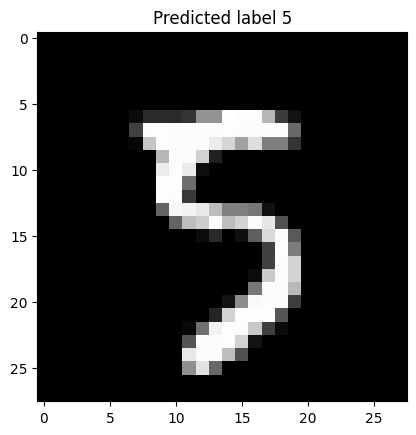

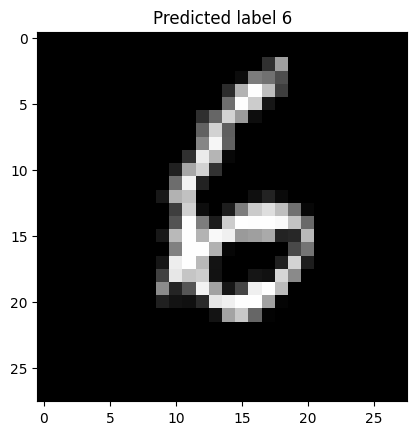

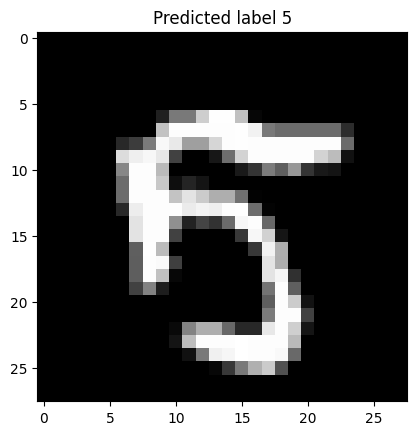

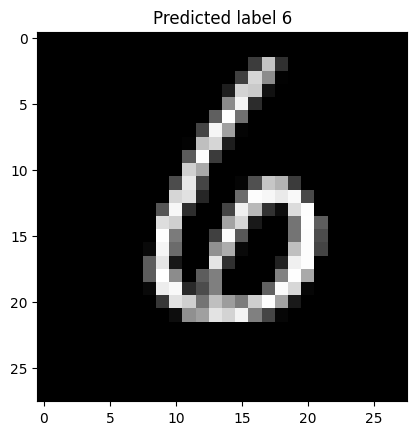

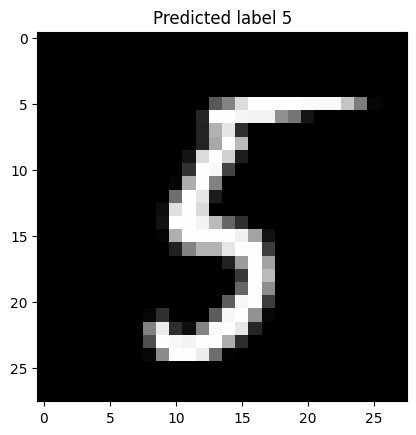

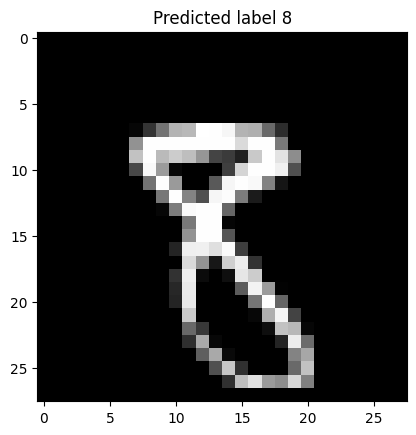

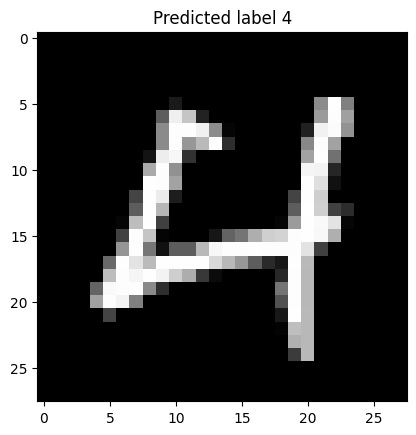

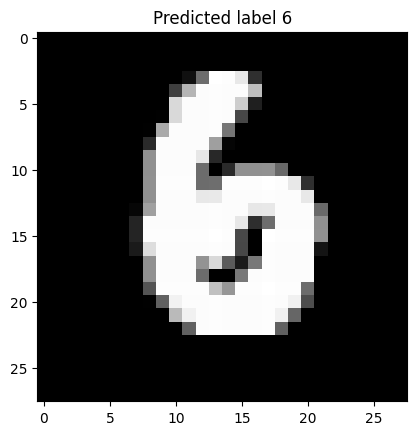

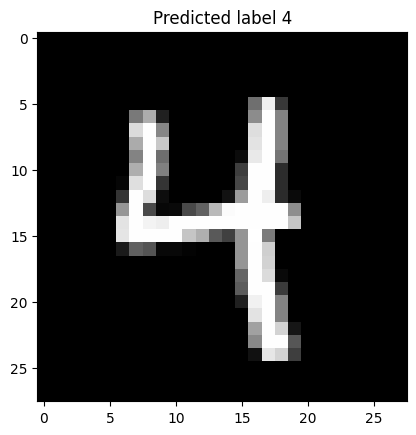

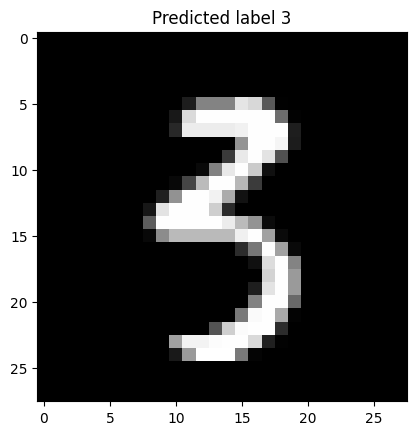

In [55]:
#Mostrar la prediccion y el número
for i in range(10):
    img=X_test_tarea.values[i].reshape((28,28))
    plt.title('Predicted label {0}'.format(y_pred_tarea[i]))
    plt.imshow(img,cmap='gray')
    plt.show()

In [56]:
# * Evaluar el archivo datos/mnist_evaluacion_pixeles.txt, asignar etiquetas a los datos y guardar los resultados en un archivo de texto.
#      * np.savetxt('NOMBRE1_NOMBRE2_NOMBRE3.txt', y_pred, fmt='%d', delimiter=',')

df_mnist_evaluacion = pd.read_csv('datos/mnist_evaluacion_pixeles.txt', header=None, dtype='uint8')
df_mnist_evaluacion.head()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [77]:
y_pred_evaluar = grid_SVM.predict(df_mnist_evaluacion)

In [80]:
# Los guardamos en una archivo llamado  mnist_prediccion_tarea.txt
np.savetxt('Aque_Gonzalez_Manuel_Jose.txt',y_pred_evaluar, fmt='%d' , delimiter=',')

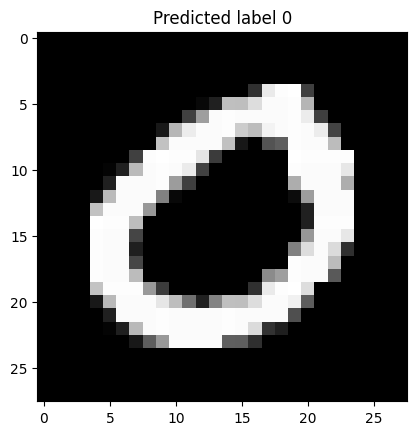

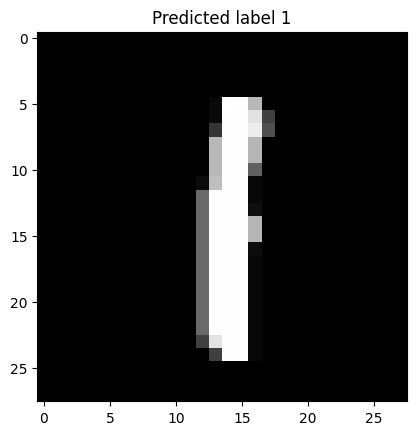

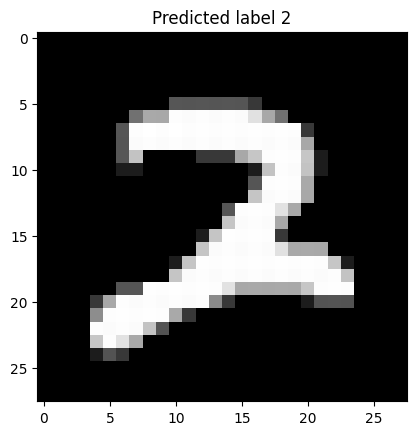

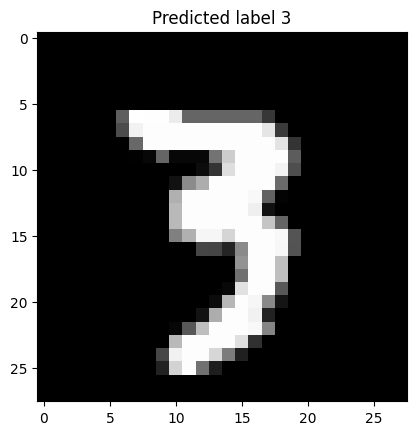

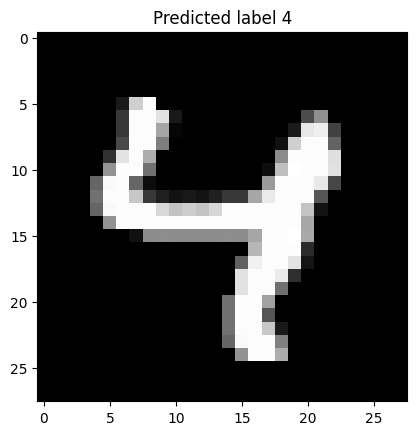

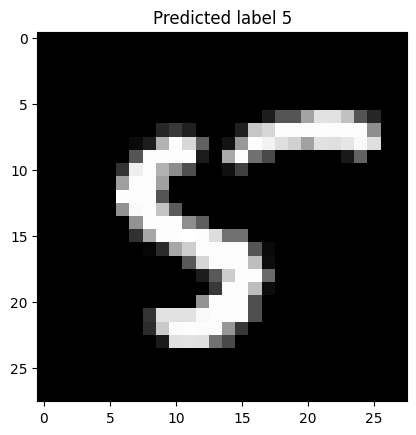

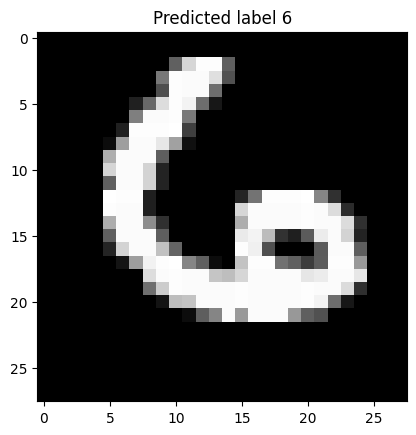

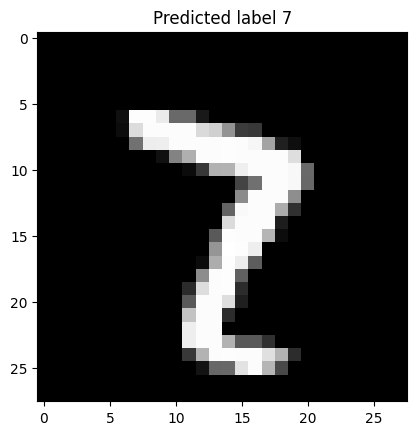

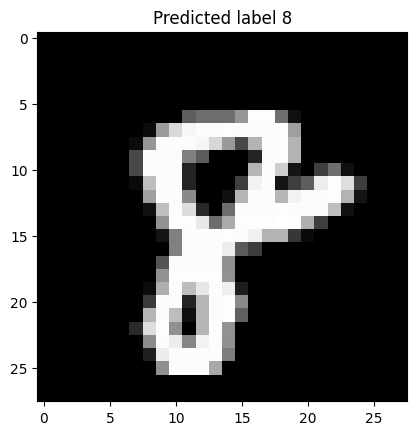

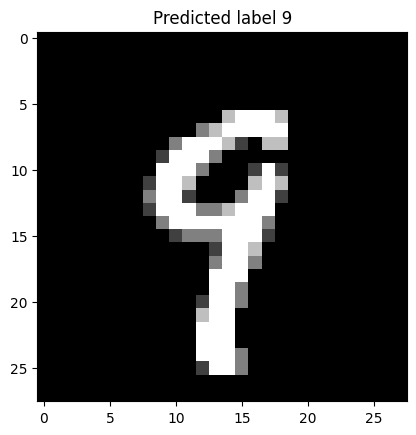

In [81]:
#Mostrar la prediccion y el número
for i in range(10):
    img=df_mnist_evaluacion.values[i].reshape((28,28))
    plt.title('Predicted label {0}'.format(y_pred_evaluar[i]))
    plt.imshow(img,cmap='gray')
    plt.show()